In [23]:
import pandas as pd
import boto3


Construct a giant DataFrame containing all of the events across the entire dataset. 
For example, you can use a loop to load each of the hourly files into a Pandas DataFrame, then combine each of these hourly DataFrames into one giant DataFrame using pd.concat().

In [24]:
s3 = boto3.client("s3")

bucket_name = "dsan6000-eak140"

response = s3.list_objects_v2(
    Bucket=bucket_name,
    Prefix="wikipedia-hourly/"
)

file_keys = [
    obj["Key"]
    for obj in response.get("Contents", [])
    if obj["Key"].endswith(".parquet")
]

file_keys

['wikipedia-hourly/20260901_040000.parquet',
 'wikipedia-hourly/20260901_050000.parquet',
 'wikipedia-hourly/20260901_060000.parquet',
 'wikipedia-hourly/20260901_070000.parquet',
 'wikipedia-hourly/20260901_080000.parquet',
 'wikipedia-hourly/20260901_090000.parquet',
 'wikipedia-hourly/20260901_100000.parquet',
 'wikipedia-hourly/20260901_110000.parquet',
 'wikipedia-hourly/20260901_120000.parquet',
 'wikipedia-hourly/20260901_130000.parquet',
 'wikipedia-hourly/20260901_140000.parquet',
 'wikipedia-hourly/20260901_150000.parquet',
 'wikipedia-hourly/20260901_160000.parquet',
 'wikipedia-hourly/20260901_170000.parquet',
 'wikipedia-hourly/20260901_180000.parquet',
 'wikipedia-hourly/20260901_190000.parquet',
 'wikipedia-hourly/20260901_200000.parquet',
 'wikipedia-hourly/20260901_210000.parquet',
 'wikipedia-hourly/20260901_220000.parquet',
 'wikipedia-hourly/20260901_230000.parquet',
 'wikipedia-hourly/20260902_000000.parquet',
 'wikipedia-hourly/20260902_010000.parquet',
 'wikipedi

In [25]:
hourly_dfs = []

for key in file_keys:
    s3_uri = f"s3://{bucket_name}/{key}"
    hour_df = pd.read_parquet(s3_uri)
    hourly_dfs.append(hour_df)

In [26]:
all_df = pd.concat(hourly_dfs, ignore_index=True)
all_df.head()


,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


Use seaborn to produce two line plots visualizing hourly event count.

In the first plot, visualize the total number of events per hour. 


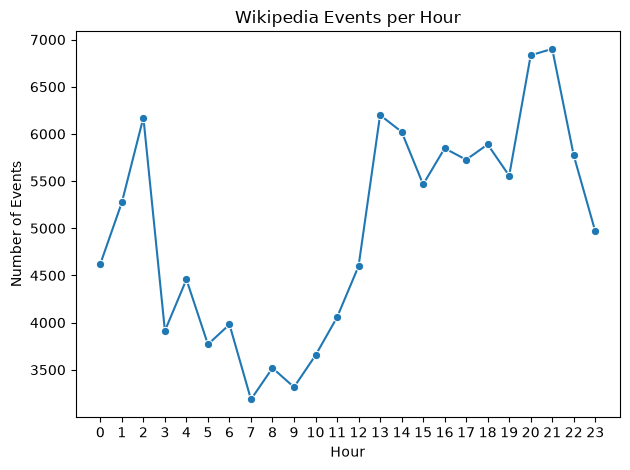

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

hourly_counts = (
    all_df
    .assign(hour=pd.to_datetime(all_df["datetime"]).dt.hour)
    .groupby("hour")
    .size()
    .reset_index(name="event_count")
)

sns.lineplot(
    data=hourly_counts,
    x="hour",
    y="event_count",
    marker="o"
)

plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.title("Wikipedia Events per Hour")
plt.tight_layout()

plt.savefig("images/hourly-events.png")
plt.savefig("images/hourly-events.svg")

plt.show()

In the second plot, visualize the hourly event counts by type.

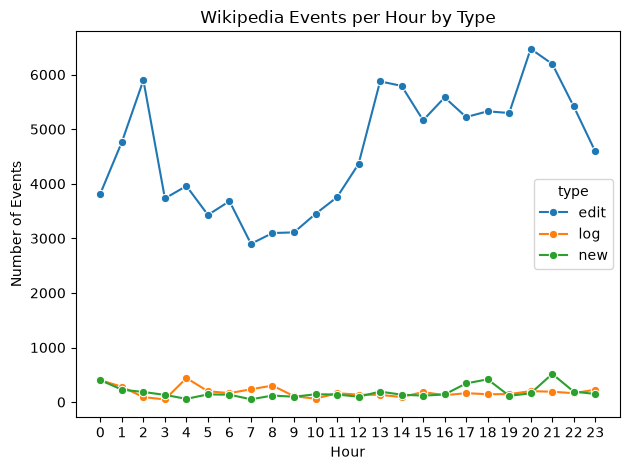

In [28]:
hourly_type_counts = (
    all_df
    .assign(hour=pd.to_datetime(all_df["datetime"]).dt.hour)
    .groupby(["hour", "type"])
    .size()
    .reset_index(name="event_count")
)

sns.lineplot(
    data=hourly_type_counts,
    x="hour",
    y="event_count",
    hue="type",
    marker="o"
)

plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.title("Wikipedia Events per Hour by Type")
plt.tight_layout()

plt.savefig("images/events-by-type.png")
plt.savefig("images/events-by-type.svg")

plt.show()